# Testing Done

In [ ]:
import numpy as np
import pandas as pd
df = pd.read_csv(r'D:\PYTHON-LEARING-DJANGO\Machine-Learning\spam.csv', encoding='latin-1')
df.head(10)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
5,spam,FreeMsg Hey there darling it's been 3 week's n...,NaN,NaN,NaN
6,ham,Even my brother is not like to speak with me. ...,NaN,NaN,NaN
7,ham,As per your request 'Melle Melle (Oru Minnamin...,NaN,NaN,NaN
8,spam,WINNER!! As a valued network customer you have...,NaN,NaN,NaN
9,spam,Had your mobile 11 months or more? U R entitle...,NaN,NaN,NaN


In [7]:
df.shape

(5572, 5)

# steps
# data cleaning
# EDA
# text processing
# model building
# evalutaion
# improvment
# frontend (react)

# data cleaning

In [ ]:
df.info()
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)


<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   v1      5572 non-null   str  
 1   v2      5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


,v1,v2
2525,ham,"Say this slowly.? GOD,I LOVE YOU &amp; I NEED ..."
1140,ham,Oh:)as usual vijay film or its different?
4021,ham,U gd lor go shopping i got stuff to do. U wan ...
5458,ham,"Sorry, I'll call later"
1461,ham,Kinda. First one gets in at twelve! Aah. Speak...
3475,ham,"I can probably come by, everybody's done aroun..."
2976,ham,"Ok omw now, you at castor?"
530,spam,PRIVATE! Your 2003 Account Statement for 07815...
4949,ham,Hi its me you are probably having too much fun...
202,ham,Your account has been refilled successfully by...


In [ ]:
df.sample(10)

,v1,v2
2912,ham,Kindly send some one to our flat before &lt;D...
5230,ham,"Nope, I'm still in the market"
3325,ham,Huh so fast... Dat means u havent finished pai...
2919,ham,"Thanx 4 the time weåÕve spent 2geva, its bin m..."
5322,ham,"Thanks, I'll keep that in mind"
2588,ham,My superior telling that friday is leave for a...
2247,spam,Back 2 work 2morro half term over! Can U C me ...
1359,ham,&lt;#&gt; %of pple marry with their lovers... ...
924,ham,Actually i deleted my old website..now i m blo...
4430,ham,2mro i am not coming to gym machan. Goodnight.


In [18]:
df.rename(columns={'v1':'label','v2':'message'},inplace=True)
df.sample(10)

,label,message
2481,ham,K.:)do it at evening da:)urgent:)
4968,ham,I will cme i want to go to hos 2morow. After t...
4165,ham,Well if I'm that desperate I'll just call arma...
2814,ham,Some are lasting as much as 2 hours. You might...
394,ham,Pick you up bout 7.30ish? What time are and t...
3121,spam,Free entry in 2 a weekly comp for a chance to ...
1699,ham,Ok...
4835,ham,Yay can't wait to party together!
544,ham,This girl does not stay in bed. This girl does...
2458,ham,"Cool, I'll text you when I'm on the way"


In [20]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['label'] = encoder.fit_transform(df['label'])
df.head(10)

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
5,1,FreeMsg Hey there darling it's been 3 week's n...
6,0,Even my brother is not like to speak with me. ...
7,0,As per your request 'Melle Melle (Oru Minnamin...
8,1,WINNER!! As a valued network customer you have...
9,1,Had your mobile 11 months or more? U R entitle...


In [21]:
# missing values check
df.isnull().sum()

label      0
message    0
dtype: int64

In [22]:
# check dublicate values
df.duplicated().sum()

np.int64(403)

In [23]:
df = df.drop_duplicates(keep='first')
df.duplicated().sum()

np.int64(0)

In [24]:
df.shape

(5169, 2)

# EDA part

In [25]:
df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [27]:
df['label'].value_counts()

label
0    4516
1     653
Name: count, dtype: int64

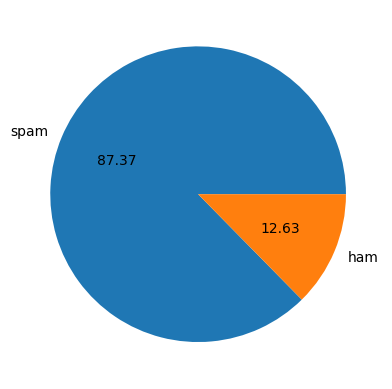

In [30]:
import matplotlib.pyplot as plt
plt.pie(df['label'].value_counts(),labels=['spam','ham'],autopct='%0.2f')
plt.show()

In [32]:
# data is unbalance
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [39]:
df['char'] = df['message'].apply(len)
df.head()

,label,message,Char,char
0,0,"Go until jurong point, crazy.. Available only ...",111,111
1,0,Ok lar... Joking wif u oni...,29,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,155
3,0,U dun say so early hor... U c already then say...,49,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61,61


In [42]:
# df.drop(columns=['Char'], inplace=True)
df.head()

,label,message,char
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [46]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [50]:
df['words'] = df['message'].apply(lambda x: len(nltk.word_tokenize(x)))


In [52]:
df.head()

,label,message,char,words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [55]:
# no of sentences
df['sentences'] = df['message'].apply(lambda x: len(nltk.sent_tokenize(x)))
df.head()


,label,message,char,words,sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [57]:
df[['char', 'words', 'sentences']].describe()

,char,words,sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [60]:
# Ham messages
df[df['label'] == 0][['char', 'words', 'sentences']].describe()

,char,words,sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [62]:
# Spam messages
df[df['label'] == 1][['char', 'words', 'sentences']].describe()

,char,words,sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='char', ylabel='Count'>

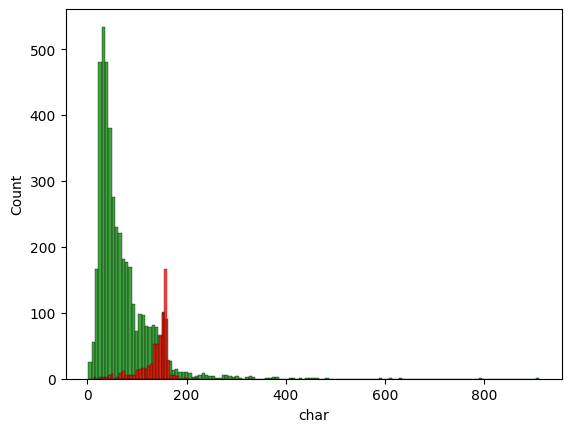

In [67]:
import seaborn as sns
sns.histplot(df[df['label'] == 0]['char'],color='green')
sns.histplot(df[df['label'] == 1]['char'],color='red')


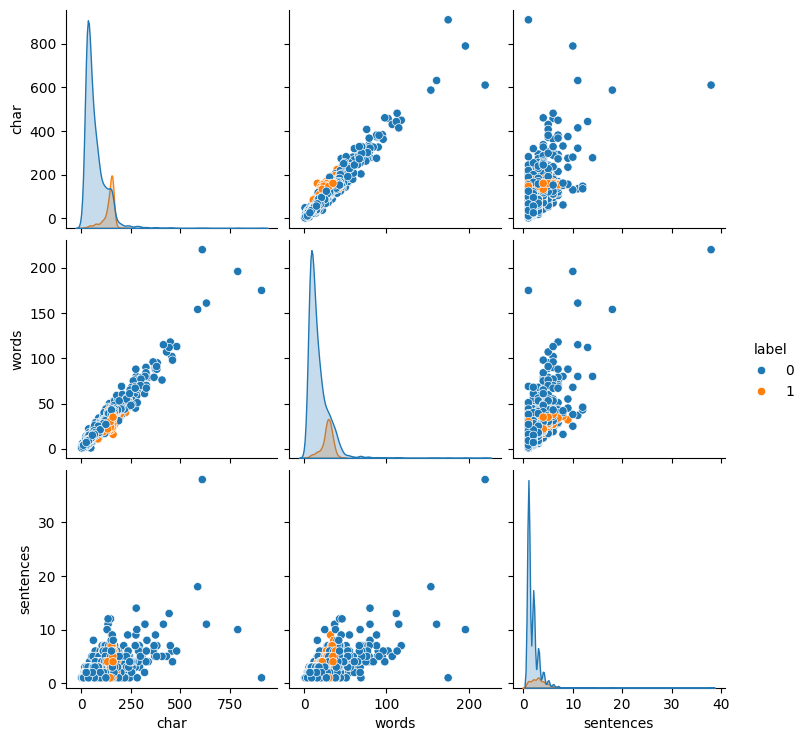

In [69]:
sns.pairplot(df,hue='label')

# Data ko sai kr rhy through Function

In [98]:
from nltk.corpus import stopwords
import string
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

def transformtext(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    var = []
    for i in text:
        if i.isalnum():
            var.append(i)

    text = var[:]
    var = []

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            var.append(i)

    text = var[:]
    var = []

    for i in text:
        var.append(ps.stem(i))

    return ' '.join(var)

In [105]:
transformtext("I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.")

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [106]:
df['message'][10]

"I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today."

In [108]:
df['filterd'] = df['message'].apply(transformtext)
df.head()

,label,message,char,words,sentences,filterd
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


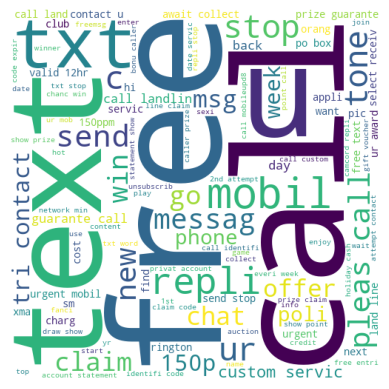

In [112]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

spam_wc = wc.generate(
    df[df['label'] == 1]['filterd'].str.cat(sep=" ")
)

plt.figure()
plt.imshow(spam_wc)
plt.axis("off")
plt.show()

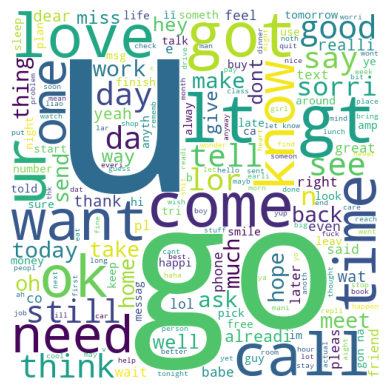

In [116]:
spam_wc = wc.generate(
    df[df['label'] == 0]['filterd'].str.cat(sep=" ")
)

plt.figure()
plt.imshow(spam_wc)
plt.axis("off")
plt.show()

In [122]:
spam_words = []
for i in df[df['label'] == 1]['filterd'].to_list():
    for j in i.split():
     spam_words.append(j)


In [124]:
len(spam_words)

9939

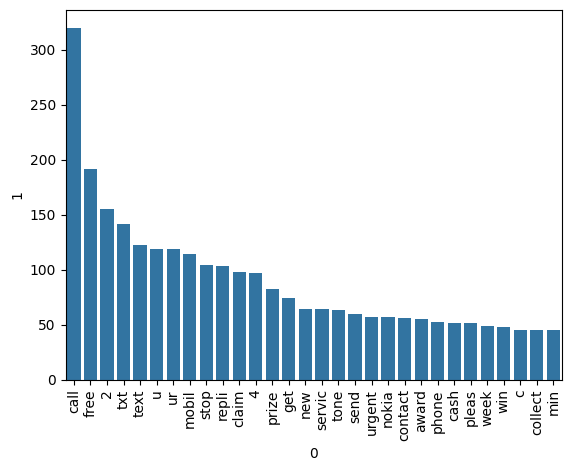

In [134]:
from collections import Counter
sns.barplot(
    x=pd.DataFrame(Counter(spam_words).most_common(30))[0],
    y=pd.DataFrame(Counter(spam_words).most_common(30))[1]
)
plt.xticks(rotation='vertical')
plt.show()


In [136]:
ham_words = []
for i in df[df['label'] == 0]['filterd'].to_list():
    for j in i.split():
     ham_words.append(j)
     


In [138]:
len(ham_words)

35404

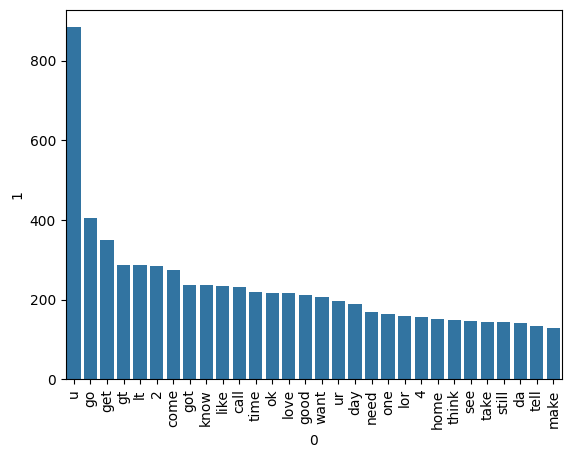

In [141]:
sns.barplot(
    x=pd.DataFrame(Counter(ham_words).most_common(30))[0],
    y=pd.DataFrame(Counter(ham_words).most_common(30))[1]
)
plt.xticks(rotation='vertical')
plt.show()

# Model training

In [146]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfid = TfidfVectorizer(max_features=3000) 
X = tfid.fit_transform(df['filterd']).toarray()
print(X.shape)
print(X)
print(df.columns)

(5169, 3000)
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
Index(['label', 'message', 'char', 'words', 'sentences', 'filterd'], dtype='str')


In [148]:
Y = df['label']

In [150]:
print(Y.shape)
print(Y.head())

(5169,)
0    0
1    0
2    1
3    0
4    0
Name: label, dtype: int64


In [152]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=2)
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(4135, 3000)
(1034, 3000)
(4135,)
(1034,)


In [154]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(X_train,Y_train)
print(model)

MultinomialNB()


In [156]:
y_pred = model.predict(X_test)
print(y_pred)

[0 0 0 ... 0 0 0]


In [159]:
from sklearn.metrics import accuracy_score, precision_score
print("Accuracy:", accuracy_score(Y_test, y_pred))
print("Precision:", precision_score(Y_test, y_pred))

Accuracy: 0.9709864603481625
Precision: 1.0


In [160]:
import pickle
pickle.dump(tfid,open('vectorized.pkl','wb'))
pickle.dump(model,open('model.pkl','wb'))